In [3]:
import pandas as pd
import os

BASE_DIR = "C:/Tesis"


## Filtrado

In [4]:
FILE_PATH = os.path.join(BASE_DIR, "bbdd_filtrada.csv")
CHUNK_SIZE = 1_000_000
STORE_NBR = 44

tamano_gb = os.path.getsize(FILE_PATH) / (1024**3)
print(f"Tamaño en disco: {tamano_gb:.2f} GB")


Tamaño en disco: 0.22 GB


In [5]:
partes = []

for i, chunk in enumerate(pd.read_csv(FILE_PATH, chunksize=CHUNK_SIZE, parse_dates=["date"])):
    partes.append(chunk[chunk["store_nbr"] == STORE_NBR])

    if (i + 1) % 5 == 0:
        print(f"Procesadas {(i + 1) * CHUNK_SIZE:,} filas leídas del archivo...")

bbdd_filtrada = pd.concat(partes, ignore_index=True)
print(f"\nFilas de la tienda 44: {len(bbdd_filtrada):,}")



Filas de la tienda 44: 1,599,702


## Revisión rápida

In [6]:
bbdd_filtrada.info()


<class 'pandas.DataFrame'>
RangeIndex: 1599702 entries, 0 to 1599701
Data columns (total 21 columns):
 #   Column        Non-Null Count    Dtype         
---  ------        --------------    -----         
 0   id            1599702 non-null  int64         
 1   date          1599702 non-null  datetime64[us]
 2   store_nbr     1599702 non-null  int64         
 3   item_nbr      1599702 non-null  int64         
 4   unit_sales    1599702 non-null  float64       
 5   onpromotion   1599702 non-null  bool          
 6   city          1599702 non-null  str           
 7   state         1599702 non-null  str           
 8   store_type    1599702 non-null  str           
 9   cluster       1599702 non-null  int64         
 10  transactions  1594596 non-null  float64       
 11  class         1599702 non-null  int64         
 12  perishable    1599702 non-null  int64         
 13  Category      1599702 non-null  str           
 14  holiday_type  1599702 non-null  str           
 15  locale   

In [7]:
bbdd_filtrada.head(10)


,id,date,store_nbr,item_nbr,unit_sales,onpromotion,city,state,store_type,cluster,...,class,perishable,Category,holiday_type,locale,locale_name,description,transferred,dcoilwtico,is_holiday
0,66538108,2016-01-02,44,103520,8.0,False,Quito,Pichincha,A,5,...,1028,0,Grocery I,no_holiday,no_holiday,no_holiday,no_holiday,False,36.81,False
1,66538111,2016-01-02,44,105575,47.0,False,Quito,Pichincha,A,5,...,1045,0,Grocery I,no_holiday,no_holiday,no_holiday,no_holiday,False,36.81,False
2,66538112,2016-01-02,44,105577,1.0,False,Quito,Pichincha,A,5,...,1045,0,Grocery I,no_holiday,no_holiday,no_holiday,no_holiday,False,36.81,False
3,66538113,2016-01-02,44,105693,4.0,False,Quito,Pichincha,A,5,...,1034,0,Grocery I,no_holiday,no_holiday,no_holiday,no_holiday,False,36.81,False
4,66538114,2016-01-02,44,105737,32.0,False,Quito,Pichincha,A,5,...,1044,0,Grocery I,no_holiday,no_holiday,no_holiday,no_holiday,False,36.81,False
5,66538115,2016-01-02,44,105857,24.0,False,Quito,Pichincha,A,5,...,1092,0,Grocery I,no_holiday,no_holiday,no_holiday,no_holiday,False,36.81,False
6,66538116,2016-01-02,44,106716,9.0,False,Quito,Pichincha,A,5,...,1032,0,Grocery I,no_holiday,no_holiday,no_holiday,no_holiday,False,36.81,False
7,66538117,2016-01-02,44,108634,38.0,False,Quito,Pichincha,A,5,...,1075,0,Grocery I,no_holiday,no_holiday,no_holiday,no_holiday,False,36.81,False
8,66538110,2016-01-02,44,105574,22.0,False,Quito,Pichincha,A,5,...,1045,0,Grocery I,no_holiday,no_holiday,no_holiday,no_holiday,False,36.81,False
9,66538118,2016-01-02,44,108696,11.0,False,Quito,Pichincha,A,5,...,2636,1,Deli,no_holiday,no_holiday,no_holiday,no_holiday,False,36.81,False


## Filtro de holidays (is_holiday) y relleno de oil (dcoilwtico)

In [8]:
# --- Filtro de holidays_events ---
# Rellenar valores nulos en las columnas de texto de holidays_events como 'no_holiday'
cols_holiday_texto = ["holiday_type", "locale", "locale_name", "description"]
for col in cols_holiday_texto:
    bbdd_filtrada[col] = bbdd_filtrada[col].fillna("no_holiday")

# 'transferred' es booleana; los NaN corresponden a fechas sin feriado -> False
bbdd_filtrada["transferred"] = bbdd_filtrada["transferred"].fillna(False).astype(bool)

# Columna is_holiday: True si es feriado nacional, o local de Quito/Pichincha
# (la tienda 44 está ubicada en Quito, Pichincha, así que estos son los feriados que la afectan)
bbdd_filtrada["is_holiday"] = (
    (bbdd_filtrada["locale"] == "National") |
    (bbdd_filtrada["locale_name"].str.lower().isin(["quito", "pichincha"]))
)

print(bbdd_filtrada["is_holiday"].value_counts())


is_holiday
False    1437271
True      162431
Name: count, dtype: int64


In [9]:
# --- Relleno de dcoilwtico (precio del petróleo) ---
# El petróleo no cotiza fines de semana/feriados, por eso hay NaN en esas fechas.
# Se ordena por fecha y se aplica forward-fill (arrastra el último valor conocido);
# se agrega un backward-fill solo por si la serie empieza con NaN (sin dato previo).
bbdd_filtrada = bbdd_filtrada.sort_values("date").reset_index(drop=True)

n_nulos_antes = bbdd_filtrada["dcoilwtico"].isna().sum()

bbdd_filtrada["dcoilwtico"] = bbdd_filtrada["dcoilwtico"].ffill()
bbdd_filtrada["dcoilwtico"] = bbdd_filtrada["dcoilwtico"].bfill()

n_nulos_despues = bbdd_filtrada["dcoilwtico"].isna().sum()
print(f"Nulos en dcoilwtico antes: {n_nulos_antes:,}")
print(f"Nulos en dcoilwtico después: {n_nulos_despues:,}")


Nulos en dcoilwtico antes: 0
Nulos en dcoilwtico después: 0


In [10]:
# Revisión rápida del resultado
bbdd_filtrada[["date", "holiday_type", "locale", "locale_name", "is_holiday", "dcoilwtico"]].head(10)


,date,holiday_type,locale,locale_name,is_holiday,dcoilwtico
0,2016-01-02,no_holiday,no_holiday,no_holiday,False,36.81
1,2016-01-02,no_holiday,no_holiday,no_holiday,False,36.81
2,2016-01-02,no_holiday,no_holiday,no_holiday,False,36.81
3,2016-01-02,no_holiday,no_holiday,no_holiday,False,36.81
4,2016-01-02,no_holiday,no_holiday,no_holiday,False,36.81
5,2016-01-02,no_holiday,no_holiday,no_holiday,False,36.81
6,2016-01-02,no_holiday,no_holiday,no_holiday,False,36.81
7,2016-01-02,no_holiday,no_holiday,no_holiday,False,36.81
8,2016-01-02,no_holiday,no_holiday,no_holiday,False,36.81
9,2016-01-02,no_holiday,no_holiday,no_holiday,False,36.81


## Estadística descriptiva

### Nulos y duplicados

In [11]:
# Nulos por columna
nulos = bbdd_filtrada.isna().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
print("Columnas con valores nulos:")
print(nulos)


Columnas con valores nulos:
transactions    5106
dtype: int64


In [12]:
# Duplicados por 'id' (cada fila debería ser única)
n_duplicados_id = bbdd_filtrada["id"].duplicated().sum()
print(f"Filas con 'id' duplicado: {n_duplicados_id:,}")

# Duplicados considerando toda la fila
n_duplicados_totales = bbdd_filtrada.duplicated().sum()
print(f"Filas completamente duplicadas: {n_duplicados_totales:,}")


Filas con 'id' duplicado: 0
Filas completamente duplicadas: 0


### Estadísticas descriptivas — variables numéricas

In [25]:
# describe() sobre todas las columnas numéricas
cols_numericas = bbdd_filtrada.select_dtypes(include="number").columns.tolist()
print("Columnas numéricas:", cols_numericas)

bbdd_filtrada[cols_numericas].describe().T.round(2)


Columnas numéricas: ['id', 'store_nbr', 'item_nbr', 'unit_sales', 'cluster', 'transactions', 'class', 'perishable', 'dcoilwtico']


,count,mean,std,min,25%,50%,75%,max
id,1599702.0,95878422.13,16934506.69,66538108.00,81301589.25,95726929.50,1.104718e+08,1.254739e+08
store_nbr,1599702.0,44.00,0.00,44.00,44.00,44.00,4.400000e+01,4.400000e+01
item_nbr,1599702.0,1145530.34,562790.70,96995.00,696183.00,1171140.00,1.473478e+06,2.127114e+06
unit_sales,1599702.0,16.79,37.50,-363.00,3.00,8.00,1.700000e+01,3.556000e+03
cluster,1599702.0,5.00,0.00,5.00,5.00,5.00,5.000000e+00,5.000000e+00
transactions,1594596.0,4384.18,700.21,3018.00,3842.00,4239.00,4.835000e+03,8.307000e+03
class,1599702.0,2041.25,1275.54,1002.00,1064.00,2004.00,2.712000e+03,7.780000e+03
perishable,1599702.0,0.27,0.44,0.00,0.00,0.00,1.000000e+00,1.000000e+00
dcoilwtico,1599702.0,45.81,6.29,26.19,43.62,47.24,4.985000e+01,5.448000e+01


### Estadísticas descriptivas — variables categóricas / booleanas

In [14]:
# describe() sobre columnas categóricas (incluye texto y booleanas)
cols_categoricas = bbdd_filtrada.select_dtypes(include=["object", "bool"]).columns.tolist()
print("Columnas categóricas:", cols_categoricas)

bbdd_filtrada[cols_categoricas].describe().T


C:\Users\Laury\AppData\Local\Temp\ipykernel_28548\325766769.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols_categoricas = bbdd_filtrada.select_dtypes(include=["object", "bool"]).columns.tolist()


Columnas categóricas: ['onpromotion', 'city', 'state', 'store_type', 'Category', 'holiday_type', 'locale', 'locale_name', 'description', 'transferred', 'is_holiday']


,count,unique,top,freq
onpromotion,1599702,2,False,1449330
city,1599702,1,Quito,1599702
state,1599702,1,Pichincha,1599702
store_type,1599702,1,A,1599702
Category,1599702,32,Grocery I,527210
holiday_type,1599702,6,no_holiday,1333417
locale,1599702,4,no_holiday,1333417
locale_name,1599702,23,no_holiday,1333417
description,1599702,76,no_holiday,1333417
transferred,1599702,2,False,1583915


In [15]:
# Detalle de frecuencias para las categóricas más relevantes
cols_categoricas_clave = [
    "family", "store_type", "city", "state",
    "holiday_type", "locale", "locale_name",
    "is_holiday", "onpromotion", "transferred"
]

for col in cols_categoricas_clave:
    if col in bbdd_filtrada.columns:
        print(f"\n--- {col} ---")
        print(bbdd_filtrada[col].value_counts(dropna=False))



--- store_type ---
store_type
A    1599702
Name: count, dtype: int64

--- city ---
city
Quito    1599702
Name: count, dtype: int64

--- state ---
state
Pichincha    1599702
Name: count, dtype: int64

--- holiday_type ---
holiday_type
no_holiday    1333417
Holiday        134289
Event           78374
Additional      33853
Transfer        16955
Bridge           2814
Name: count, dtype: int64

--- locale ---
locale
no_holiday    1333417
National       156739
Local           95327
Regional        14219
Name: count, dtype: int64

--- locale_name ---
locale_name
no_holiday                        1333417
Ecuador                            156739
Guayaquil                           10735
Riobamba                            10695
Cuenca                               8056
Guaranda                             7935
Cotopaxi                             5703
Quito                                5692
Cayambe                              5661
El Carmen                            5619
Esmeraldas       

### `unit_sales` según `is_holiday` y `onpromotion`

In [16]:
# Estadísticas de unit_sales agrupadas por is_holiday
resumen_holiday = bbdd_filtrada.groupby("is_holiday")["unit_sales"].agg(
    n="count", media="mean", mediana="median", desv_std="std", minimo="min", maximo="max"
)
print("unit_sales por is_holiday:")
resumen_holiday


unit_sales por is_holiday:


,n,media,mediana,desv_std,minimo,maximo
is_holiday,,,,,,
False,1437271,16.545622,8.0,36.416109,-363.0,3556.0
True,162431,18.931424,9.0,45.967264,-108.0,3009.0


In [17]:
# Estadísticas de unit_sales agrupadas por onpromotion
resumen_promo = bbdd_filtrada.groupby("onpromotion")["unit_sales"].agg(
    n="count", media="mean", mediana="median", desv_std="std", minimo="min", maximo="max"
)
print("unit_sales por onpromotion:")
resumen_promo


unit_sales por onpromotion:


,n,media,mediana,desv_std,minimo,maximo
onpromotion,,,,,,
False,1449330,15.539549,7.4625,34.122914,-363.0,3009.0
True,150372,28.819583,14.0000,59.840877,-2.0,3556.0


In [18]:
# Cruce is_holiday x onpromotion: media de unit_sales en cada combinación
resumen_cruzado = bbdd_filtrada.groupby(["is_holiday", "onpromotion"])["unit_sales"].agg(
    n="count", media="mean", mediana="median"
)
print("unit_sales por is_holiday x onpromotion:")
resumen_cruzado


unit_sales por is_holiday x onpromotion:


n      media  mediana
is_holiday onpromotion                             
False      False        1303176  15.284782      7.0
           True          134095  28.798848     14.0
True       False         146154  17.811167      8.0
           True           16277  28.990408     14.0

### Distribución de categorías (`family`)

In [21]:
# Conteo y porcentaje de cada categoría (family)
distribucion_family = bbdd_filtrada["Category"].value_counts().reset_index()
distribucion_family.columns = ["Category", "n"]
distribucion_family["porcentaje"] = (distribucion_family["n"] / len(bbdd_filtrada) * 100).round(2)

print(f"Total de categorías distintas: {bbdd_filtrada['Category'].nunique()}")
distribucion_family


Total de categorías distintas: 32


,Category,n,porcentaje
0,Grocery I,527210,32.96
1,Beverages,243800,15.24
2,Cleaning,180488,11.28
3,Produce,130852,8.18
4,Dairy,116425,7.28
5,Bread & Bakery,57304,3.58
6,Personal Care,57283,3.58
7,Home Care,44627,2.79
8,Deli,41010,2.56
9,Meats,30519,1.91


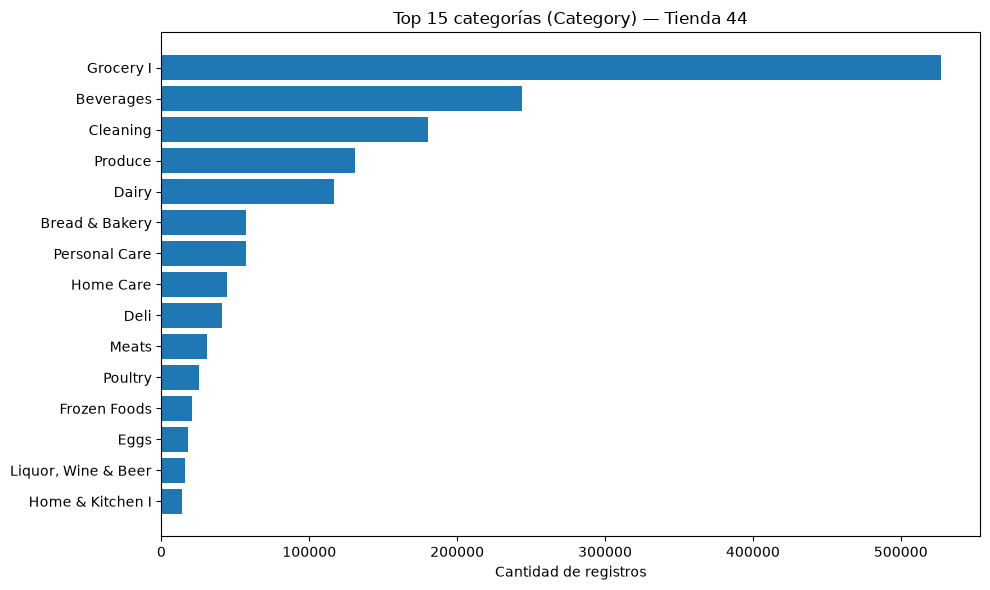

In [23]:
import matplotlib.pyplot as plt

# Gráfico de barras con las categorías más frecuentes
TOP_N = 15
top_categorias = distribucion_family.head(TOP_N)

plt.figure(figsize=(10, 6))
plt.barh(top_categorias["Category"][::-1], top_categorias["n"][::-1])
plt.xlabel("Cantidad de registros")
plt.title(f"Top {TOP_N} categorías (Category) — Tienda 44")
plt.tight_layout()
plt.show()
